## 1. Carregamento dos dados

Carregamos o dataset bruto (`articles.csv`) da Folha de S.Paulo.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_colwidth', 100)

# Encontra a raiz do projeto de forma robusta, independente de onde o notebook é executado
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'articles.csv'

print(f"Lendo de: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head(3)

Lendo de: c:\Users\Marco\Desktop\Arquivos MARCO\Data-Science-Case\news-classifier\data\raw\articles.csv
Shape: (167053, 6)


,title,text,date,category,subcategory,link
0,"Lula diz que está 'lascado', mas que ainda tem força como cabo eleitoral","Com a possibilidade de uma condenação impedir sua candidatura em 2018, o ex-presidente Luiz Inác...",2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/1925743-lula-diz-que-esta-lascado-mas-que-ainda-tem-f...
1,"'Decidi ser escrava das mulheres que sofrem', diz cantora Oumou Sangaré","Para Oumou Sangaré, cantora e ativista malinesa, o sofrimento da mulher é universal. ""Canto com ...",2017-09-10,ilustrada,NaN,http://www1.folha.uol.com.br/ilustrada/2017/10/1925745-decidi-ser-escrava-das-mulheres-que-sofre...
2,Três reportagens da Folha ganham Prêmio Petrobras de Jornalismo,"Três reportagens da Folha foram vencedoras do Prêmio Petrobras de Jornalismo, anunciado na noite...",2017-09-10,poder,NaN,http://www1.folha.uol.com.br/poder/2017/10/1925789-tres-reportagens-da-folha-ganham-premio-petro...


**Interpretação:** o dataset tem 167.053 notícias e 6 colunas (`title`, `text`, `date`,
`category`, `subcategory`, `link`). Volume suficiente para treinar um classificador de texto
tradicional (TF-IDF + modelo linear) com boa robustez estatística, mesmo após eventuais cortes
de qualidade nas próximas etapas.

## 2. Estrutura geral e qualidade dos dados

Antes de qualquer decisão de modelagem, precisamos entender a completude dos dados: quais
colunas têm valores ausentes e em que proporção. Isso é especialmente relevante para `text`
(pode haver notícias sem corpo, só título) e `subcategory` (pode haver das notícias não virem com subcategoria preenchida).

In [5]:
# Estrutura geral do dataframe (tipos, contagem de não-nulos)
df.info()

print()

# Valores nulos por coluna, em número absoluto e percentual
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct})
print(resumo_nulos)

<class 'pandas.DataFrame'>
RangeIndex: 167053 entries, 0 to 167052
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   title        167053 non-null  str  
 1   text         166288 non-null  str  
 2   date         167053 non-null  str  
 3   category     167053 non-null  str  
 4   subcategory  29635 non-null   str  
 5   link         167053 non-null  str  
dtypes: str(6)
memory usage: 7.6 MB

              nulos    pct
title             0   0.00
text            765   0.46
date              0   0.00
category          0   0.00
subcategory  137418  82.26
link              0   0.00


**Interpretação:** `text` tem apenas ~0,46% de valores nulos — proporção pequena o suficiente
para simplesmente descartar essas linhas sem perda significativa de dados. Já `subcategory`
tem ~82% de nulos, **essa é a evidência que confirma nossa decisão de modelagem**: o
classificador será treinado sobre `category`, não `subcategory`, pois esta última não tem
cobertura suficiente para servir como alvo confiável de um modelo supervisionado.

## 3. Distribuição da variável-alvo (`category`)

`category` será o alvo do nosso classificador. Antes de modelar, precisamos entender quantas
classes existem, se há desbalanceamento entre elas e se existem valores anômalos que precisam
de limpeza.

Número de categorias únicas: 48

category
poder                           22022
colunas                         21622
mercado                         20970
esporte                         19730
mundo                           17130
cotidiano                       16967
ilustrada                       16345
opiniao                          4525
paineldoleitor                   4011
saopaulo                         3955
tec                              2260
tv                               2142
educacao                         2118
turismo                          1903
ilustrissima                     1411
ciencia                          1335
equilibrioesaude                 1312
sobretudo                        1057
bbc                               980
folhinha                          876
empreendedorsocial                841
comida                            828
asmais                            548
ambiente                          491
seminariosfolha                   379
serafina

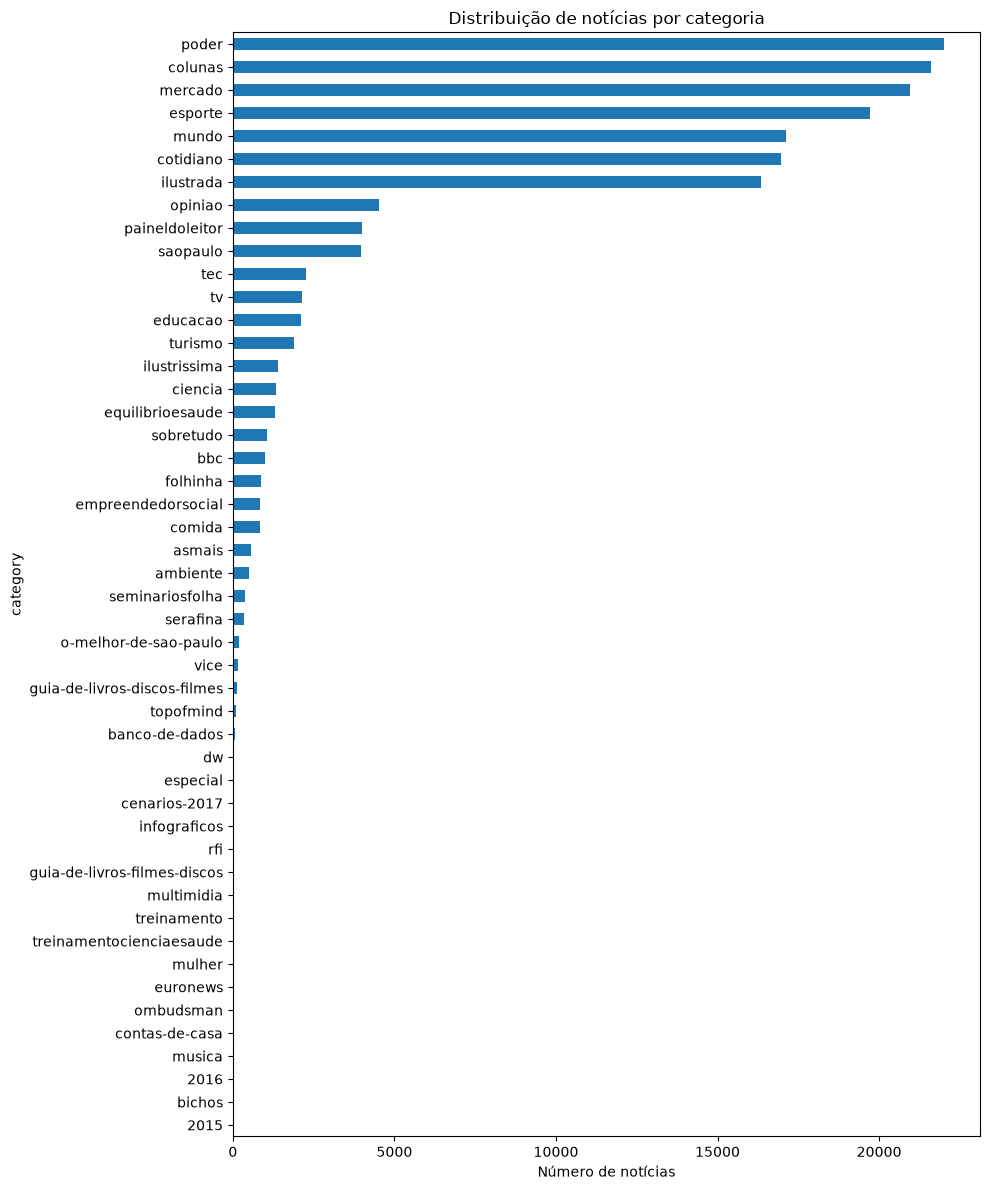

In [7]:
# Número de categorias únicas
print(f"Número de categorias únicas: {df['category'].nunique()}")
print()

# Contagem de notícias por categoria, ordenada
contagem_categorias = df['category'].value_counts()
print(contagem_categorias)

# Visualização
plt.figure(figsize=(10, 12))
contagem_categorias.plot(kind='barh')
plt.xlabel('Número de notícias')
plt.title('Distribuição de notícias por categoria')
plt.gca().invert_yaxis()
plt.tight_layout()

FIGURES_PATH = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)  # garante que a pasta existe
plt.savefig(FIGURES_PATH / 'distribuicao_categorias.png', dpi=100)
plt.show()

**Nota técnica sobre caminhos de arquivo:** em vez de usar caminhos relativos fixos (ex.
`../data/raw/articles.csv`), o carregamento dos dados usa `pathlib.Path` combinado com
`Path.cwd()` para resolver a raiz do projeto dinamicamente. Isso é uma decisão deliberada,
não um detalhe acidental: o diretório de trabalho de um notebook Jupyter pode variar
dependendo de como e de onde ele é executado (VS Code, JupyterLab, terminal, CI/CD), então
depender de um caminho relativo fixo torna o código frágil e não-reprodutível fora do
ambiente exato do autor. Essa mesma lógica de resolução de caminhos será reaproveitada nos
módulos de produção (`src/news_classifier/`), garantindo que o carregamento de dados funcione
de forma consistente independentemente de onde o código for executado.

**Interpretação:** identificamos 48 valores distintos em `category`, com desbalanceamento
extremo, as 3 maiores categorias (`poder`: 22.022, `colunas`: 21.622, `mercado`: 20.970)
concentram juntas mais de 60 mil notícias (~37% do dataset), enquanto diversas categorias têm
poucas centenas de exemplos ou menos. No extremo oposto, encontramos categorias com apenas
1 a 3 registros, incluindo dois valores claramente inválidos — `"2016"` e `"2015"` — que não
são categorias editoriais reais, e sim erro de parsing na coleta original dos dados (provavelmente
uma data que vazou para a coluna errada). Esses valores serão removidos na etapa de
pré-processamento.

Esse desbalanceamento extremo é a evidência central que vai guiar minha estratégia de
modelagem: treinar um classificador multiclasse com as 48 categorias originais seria
tecnicamente incorreto, já que categorias com 1-3 exemplos não oferecem dados suficientes
para o modelo aprender nenhum padrão generalizável, e distorceriam as métricas agregadas
(especialmente F1 macro).

## 4. Limpeza de categorias inválidas e definição de limiar mínimo

Com base no diagnóstico anterior, vamos: (1) remover os registros com valores de `category`
claramente inválidos (`"2016"`, `"2015"`) e (2) avaliar o impacto de diferentes limiares
mínimos de exemplos por categoria, para decidir de forma justificada como tratar as categorias raras antes da modelagem.

In [8]:
# Remove registros com category inválida (erro de parsing na coleta original)
categorias_invalidas = ['2016', '2015']
df_limpo = df[~df['category'].isin(categorias_invalidas)].copy()

print(f"Linhas removidas: {len(df) - len(df_limpo)}")
print(f"Shape após remoção: {df_limpo.shape}")
print()

# Avalia o impacto de diferentes limiares mínimos de exemplos por categoria
contagem = df_limpo['category'].value_counts()

for limiar in [50, 100, 200, 500]:
    categorias_abaixo = contagem[contagem < limiar]
    linhas_afetadas = categorias_abaixo.sum()
    print(f"Limiar {limiar:>4}: {len(categorias_abaixo):>2} categorias abaixo do limiar "
          f"({linhas_afetadas:>6} linhas, {linhas_afetadas/len(df_limpo)*100:.2f}% do dataset)")

Linhas removidas: 2
Shape após remoção: (167051, 6)

Limiar   50: 15 categorias abaixo do limiar (   331 linhas, 0.20% do dataset)
Limiar  100: 17 categorias abaixo do limiar (   481 linhas, 0.29% do dataset)
Limiar  200: 20 categorias abaixo do limiar (   959 linhas, 0.57% do dataset)
Limiar  500: 23 categorias abaixo do limiar (  2163 linhas, 1.29% do dataset)


## 5. Aplicação do corte final de categorias raras

Com base na análise de limiares acima, opto por um corte de **200 exemplos mínimos por
categoria**. Esse valor equilibra dois objetivos: preservar o máximo de dados possível
(perda de apenas 0,57%) e garantir volume suficiente por classe para uma validação cruzada
estável durante a modelagem. Categorias abaixo do limiar serão **excluídas** (não agrupadas
em uma classe "outras"), pois são semanticamente heterogêneas entre si, misturá-las criaria
uma classe artificial sem padrão aprendível, prejudicando a qualidade do classificador em
vez de ajudar.

In [9]:
LIMIAR_MINIMO = 200

contagem_final = df_limpo['category'].value_counts()
categorias_validas = contagem_final[contagem_final >= LIMIAR_MINIMO].index.tolist()
categorias_excluidas = contagem_final[contagem_final < LIMIAR_MINIMO].index.tolist()

df_final = df_limpo[df_limpo['category'].isin(categorias_validas)].copy()

print(f"Categorias mantidas: {len(categorias_validas)}")
print(f"Categorias excluídas: {len(categorias_excluidas)}")
print(f"Categorias excluídas: {categorias_excluidas}")
print()
print(f"Shape final: {df_final.shape} (era {df.shape})")
print(f"Percentual de dados mantido: {len(df_final)/len(df)*100:.2f}%")

Categorias mantidas: 26
Categorias excluídas: 20
Categorias excluídas: ['o-melhor-de-sao-paulo', 'vice', 'guia-de-livros-discos-filmes', 'topofmind', 'banco-de-dados', 'dw', 'especial', 'cenarios-2017', 'infograficos', 'rfi', 'guia-de-livros-filmes-discos', 'multimidia', 'treinamento', 'treinamentocienciaesaude', 'mulher', 'euronews', 'ombudsman', 'contas-de-casa', 'musica', 'bichos']

Shape final: (166092, 6) (era (167053, 6))
Percentual de dados mantido: 99.42%


**Interpretação:** aplicando o corte de 200 exemplos mínimos, o dataset final ficou com
**26 categorias** (de 48 originais) e **166.092 registros** — uma perda de apenas 0,58% do
volume total. As categorias excluídas (ex. `vice`, `dw`, `rfi`, `euronews`, `musica`, `bichos`,
`treinamento`) são majoritariamente cadernos pontuais, parcerias editoriais externas ou
conteúdo muito específico, sem coerência temática suficiente entre si para justificar
agrupamento em uma classe única. O dataset resultante (`df_final`) será a base para as
próximas etapas de pré-processamento e modelagem.

## 6. Distribuição do comprimento de título e texto

Analisamos o tamanho (em número de caracteres e palavras) de `title` e `text` por categoria.
Isso ajuda a decidir se usaremos apenas o título, apenas o texto, ou a combinação de ambos
como entrada do classificador e também revela se há textos anormalmente curtos (possíveis
notas rápidas ou legendas) que mereçam tratamento especial.

Estatísticas de comprimento do TÍTULO (em palavras):
count    166092.000000
mean         10.123064
std           2.896634
min           1.000000
25%           9.000000
50%          11.000000
75%          12.000000
max          23.000000
Name: title_len_words, dtype: float64

Estatísticas de comprimento do TEXTO (em palavras):
count    166092.000000
mean        443.774462
std         315.429630
min           0.000000
25%         249.000000
50%         392.000000
75%         563.000000
max       10434.000000
Name: text_len_words, dtype: float64


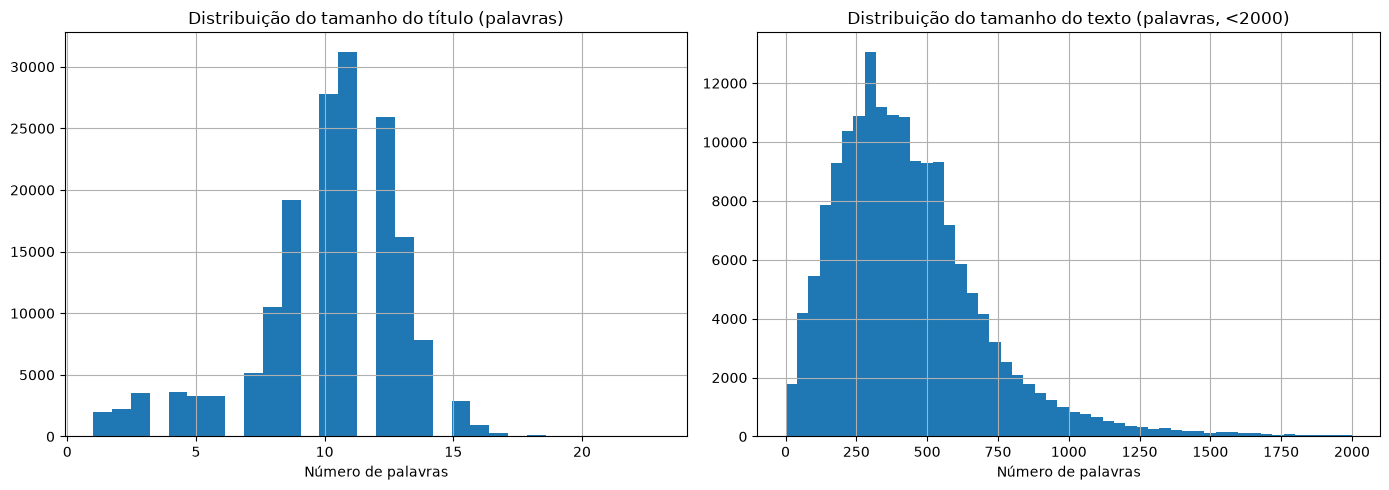

In [10]:
# Calcula comprimento em caracteres e palavras (tratando nulos em 'text' como string vazia)
df_final['title_len_chars'] = df_final['title'].str.len()
df_final['title_len_words'] = df_final['title'].str.split().str.len()

df_final['text_len_chars'] = df_final['text'].fillna('').str.len()
df_final['text_len_words'] = df_final['text'].fillna('').str.split().str.len()

print("Estatísticas de comprimento do TÍTULO (em palavras):")
print(df_final['title_len_words'].describe())
print()
print("Estatísticas de comprimento do TEXTO (em palavras):")
print(df_final['text_len_words'].describe())

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_final['title_len_words'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribuição do tamanho do título (palavras)')
axes[0].set_xlabel('Número de palavras')

df_final[df_final['text_len_words'] < 2000]['text_len_words'].hist(bins=50, ax=axes[1])
axes[1].set_title('Distribuição do tamanho do texto (palavras, <2000)')
axes[1].set_xlabel('Número de palavras')

plt.tight_layout()
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_PATH / 'distribuicao_comprimento.png', dpi=100)
plt.show()

**Interpretação:** o título tem em média **10 palavras** (mín. 1, máx. 23), uma distribuição bem concentrada, pouco espaço para variação, mas historicamente títulos de jornal são muito discriminativos por conterem vocabulário-chave da editoria. Já o texto tem em média **444 palavras**, com uma cauda longa expressiva (máximo de 10.434 palavras) e um mínimo de **0 palavras** — o que corresponde às linhas onde `text` é nulo (tratadas como string vazia) ou eventualmente vazio mesmo após preenchido.

**Decisão de modelagem:** vamos usar a **combinação de título + texto** (`title + " " + text`) como entrada do classificador, não apenas um dos dois isoladamente. O título sozinho é altamente discriminativo mas muito curto (~10 palavras) para capturar nuances; o texto sozinho tem informação rica mas mais "diluída" e nem sempre está disponível. A combinação aproveita o sinal forte e conciso do título somado ao contexto mais amplo do corpo da notícia, e mitiga o problema de textos ausentes (o título continua presente em 100% dos casos).

## 7. Textos vazios e distribuição temporal

Antes de seguir, verifico quantas notícias ficam com texto vazio (0 palavras) mesmo após o tratamento de nulos, e analiso a distribuição de notícias ao longo do tempo, isso vai embasar a decisão entre split aleatório e split temporal para treino/teste.

Notícias com texto vazio: 757 (0.46%)



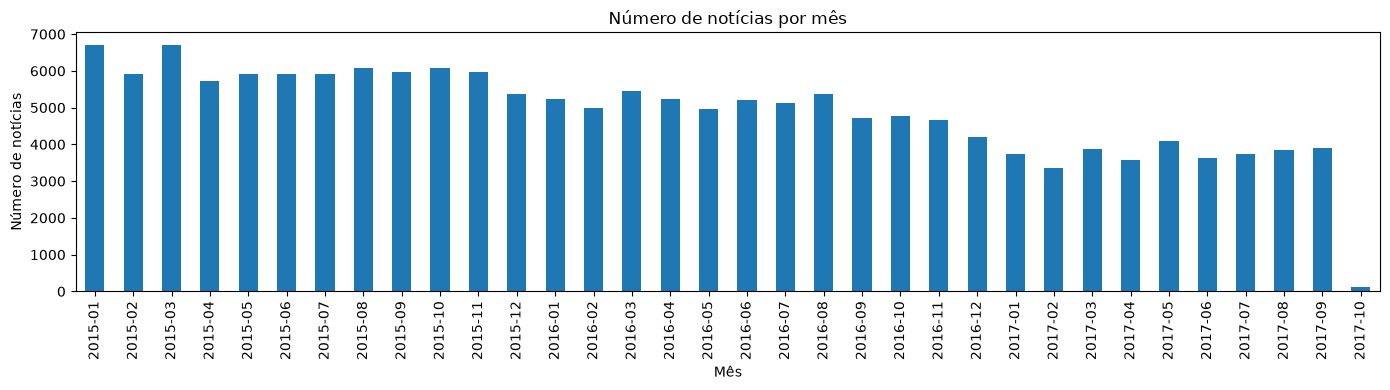


Período: 2015-01-01 00:00:00 até 2017-10-01 00:00:00


In [11]:
# Quantas notícias têm texto vazio (0 palavras)?
textos_vazios = (df_final['text_len_words'] == 0).sum()
print(f"Notícias com texto vazio: {textos_vazios} ({textos_vazios/len(df_final)*100:.2f}%)")
print()

# Distribuição temporal: notícias por mês/ano
df_final['date_parsed'] = pd.to_datetime(df_final['date'])
df_final['year_month'] = df_final['date_parsed'].dt.to_period('M')

contagem_temporal = df_final['year_month'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
contagem_temporal.plot(kind='bar')
plt.title('Número de notícias por mês')
plt.xlabel('Mês')
plt.ylabel('Número de notícias')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'distribuicao_temporal.png', dpi=100)
plt.show()

print(f"\nPeríodo: {df_final['date_parsed'].min()} até {df_final['date_parsed'].max()}")

**Interpretação:** apenas **0,46% das notícias (757)** ficaram com texto vazio mesmo após o tratamento, número residual, sem impacto relevante, e ainda assim coberto pela estratégia de combinar título + texto (o título permanece disponível nesses casos).

A distribuição temporal é razoavelmente estável ao longo dos quase 3 anos (2015-01 a 2017-10), sem lacunas relevantes ou padrões sazonais que exijam tratamento especial, a queda em 2017-10 é esperada, pois a coleta cobre apenas o primeiro dia desse mês.

**Decisão de split:** opto por um **split temporal** em vez de aleatório: treino com dados até um corte, teste com os meses finais (2017-07 a 2017-10). Isso simula de forma mais realista o cenário de produção, o modelo é treinado no "passado" e avaliado em notícias "futuras" que ele nunca viu, capturando eventual deriva de vocabulário e evitando vazamento de informação entre treino e teste, risco real dado que jornais frequentemente republicam ou atualizam notícias com títulos quase idênticos em datas próximas.

## 8. Conclusões e decisões para a modelagem

Resumo das decisões tomadas nesta EDA, que serão implementadas no pipeline de produção
(`src/news_classifier/`):

1. **Alvo do classificador:** `category` (não `subcategory`, que tem 82% de valores ausentes).
   
2. **Limpeza:** remoção de 2 registros com `category` inválida (`"2016"`, `"2015"`).
   
3. **Corte de classes raras:** exclusão de categorias com menos de 200 exemplos (20 categorias,
   0,58% dos dados), resultando em **26 categorias finais** e **166.092 registros**.

4. **Feature de entrada:** combinação de `title + text`, aproveitando o forte sinal do título
   e o contexto mais rico do texto, com tratamento de nulos (string vazia) em `text`.

5. **Estratégia de split:** split **temporal** (treino no passado, teste nos meses finais),
   em vez de aleatório, para simular um cenário realista de produção e evitar vazamento de
   dados entre notícias similares publicadas em datas próximas.

6. **Desbalanceamento remanescente:** mesmo após o corte, as 26 categorias finais ainda têm
   desbalanceamento relevante (de ~200 a ~22.000 exemplos), será tratado na etapa de
   modelagem via `class_weight='balanced'` e uso de F1 macro/weighted como métrica principal. 

Próxima etapa: construção do pipeline de pré-processamento e modelagem em `src/news_classifier/`.

**Atualização pós-EDA:** durante a implementação do pipeline de produção (`src/news_classifier/split.py`), identificamos que 4 das 26 categorias, apesar de terem volume total ≥ 200, ficavam com menos de 30 exemplos na janela de teste após o split temporal (`asmais`, `bbc`, `comida`, `folhinha`), volume insuficiente para métricas de avaliação confiáveis. Adicionamos um segundo critério de corte (mínimo de 30 exemplos na janela de teste) e o dataset final de modelagem ficou com **22 categorias**, não mais 26. Essa é uma boa demonstração de como decisões de pré-processamento às vezes só revelam problemas quando confrontadas com a divisão real dos dados e reforça a importância de validar cada etapa do pipeline, não só a EDA isolada.